# TURBO LP 空窗与价格冲击（Notebook 2A）

这一本只回答两个问题：

1. 同一钱包 Burn 后、净恢复到 80% 或 90% 之前，是否真的有 Swap 发生？
2. 这些 Swap 引起的池内价格变化，是否比同池、同方向、相近金额的非空窗交易更大？

这里研究的是 **Price Impact（交易推动池价移动多少）**，不是用户钱包最终看到的滑点。Notebook 不识别套利者，不使用 JIT 标签，也不推断交易动机。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "notebooks" / "data" / "turbo_lp_gap_impact_v1"
LEDGER_DIR = PROJECT_ROOT / "notebooks" / "data" / "turbo_lp_event_ledger_v1"

manifest = json.loads((DATA_DIR / "manifest.json").read_text())
ledger_manifest = json.loads((LEDGER_DIR / "manifest.json").read_text())
swaps = pd.read_parquet(DATA_DIR / "swaps_with_price_impact_v1.parquet")
intervals = pd.read_parquet(DATA_DIR / "gap_intervals_v1.parquet")
exposures = pd.read_parquet(DATA_DIR / "gap_swap_exposure_v1.parquet")
pairs = pd.read_parquet(DATA_DIR / "matched_swap_pairs_v1.parquet")
summary = pd.read_csv(DATA_DIR / "gap_impact_summary_v1.csv")
campaigns = pd.read_parquet(LEDGER_DIR / "lp_campaign_ledger_v1.parquet")

display(pd.Series({
    "冻结候选期": f"{ledger_manifest['cohort_from_time']} → {ledger_manifest['cohort_end_time']}",
    "后续追踪截止": ledger_manifest["followup_data_end_time"],
    "扫描 Swap": len(swaps),
    "可计算价格冲击的 Swap": int(swaps.price_impact_eligible.sum()),
    "非空窗对照候选": int((~swaps.excluded_from_controls_any_90pct_gap_24h).sum()),
    "冻结 Campaign": len(campaigns),
}, name="value").to_frame())

,value
冻结候选期,2026-06-04T03:20:59+00:00 → 2026-09-02T03:20:5...
后续追踪截止,2026-09-10T04:51:35+00:00
扫描 Swap,4880
可计算价格冲击的 Swap,4880
非空窗对照候选,3991
冻结 Campaign,159


## 1. 空窗怎么定义？

每个 campaign 从最初 Burn 的准确日志位置开始：

- **80%空窗**：到净恢复率第一次达到80%为止；
- **90%空窗**：到净恢复率第一次达到90%为止；
- 每条线再分别看最初1小时、6小时、24小时。

如果某个 campaign 后来根本没达到相应恢复线，它不进入“重建空窗”的处理组，而留给资金去向研究；但它开始后的24小时仍从正常对照中排除，避免把明显的撤资后时段冒充正常市场。

同一区块内严格按交易顺序和日志顺序判断：Burn 之前的 Swap 不算，达到恢复线的 Mint 之后的 Swap 也不算。

In [2]:
gap_rows = []
for threshold in (80, 90):
    eligible = intervals[
        intervals.threshold_pct.eq(threshold) & intervals.threshold_recovery_observed
    ].drop_duplicates("campaign_id")
    gap_minutes = (eligible.recovery_timestamp - eligible.burn_timestamp) / 60
    for horizon in ("1h", "6h", "24h"):
        current = intervals[
            intervals.threshold_pct.eq(threshold) & intervals.horizon.eq(horizon)
            & intervals.threshold_recovery_observed & intervals.observation_complete
        ]
        exposed = exposures[
            exposures.threshold_pct.eq(threshold) & exposures.horizon.eq(horizon)
        ]
        campaigns_with_swap = exposed.primary_campaign_id.nunique()
        gap_rows.append({
            "恢复线": f"{threshold}%", "观察范围": horizon,
            "可定义恢复空窗的Campaign": current.campaign_id.nunique(),
            "范围内已恢复": int(current.recovered_within_horizon.sum()),
            "空窗内有Swap的Campaign": campaigns_with_swap,
            "空窗内无Swap的Campaign": current.campaign_id.nunique() - campaigns_with_swap,
            "空窗Swap数量": len(exposed),
        })
gap_table = pd.DataFrame(gap_rows)
display(gap_table)

duration = []
for threshold in (80, 90):
    eligible = intervals[
        intervals.threshold_pct.eq(threshold) & intervals.threshold_recovery_observed
    ].drop_duplicates("campaign_id")
    values = (eligible.recovery_timestamp - eligible.burn_timestamp) / 60
    duration.append({
        "恢复线": f"{threshold}%", "Campaign数": len(values),
        "中位分钟": values.median(), "75%不超过分钟": values.quantile(.75),
        "90%不超过分钟": values.quantile(.90), "最长分钟": values.max(),
    })
duration_table = pd.DataFrame(duration)
display(Markdown("### 完整恢复空窗时长"))
display(duration_table)

,恢复线,观察范围,可定义恢复空窗的Campaign,范围内已恢复,空窗内有Swap的Campaign,空窗内无Swap的Campaign,空窗Swap数量
0,80%,1h,158,129,55,103,196
1,80%,6h,158,144,59,99,387
2,80%,24h,158,155,59,99,561
3,90%,1h,157,119,54,103,201
4,90%,6h,157,134,59,98,434
5,90%,24h,157,148,59,98,785


### 完整恢复空窗时长

,恢复线,Campaign数,中位分钟,75%不超过分钟,90%不超过分钟,最长分钟
0,80%,158,11.3,32.6,201.74,30989.8
1,90%,157,11.6,50.0,703.84,30989.8


白话解释：典型空窗很短，但分布有明显长尾。达到80%的中位时间约11.3分钟，达到90%的中位时间约11.6分钟；绝大多数很快恢复，但少数 campaign 会持续几小时甚至几天，所以不能只报一个平均数。

“空窗内没有 Swap”意味着这次短暂撤出没有碰上市场成交，不能产生我们要检验的交易价格冲击；它仍属于完整样本，只是不会进入 Swap 层面的匹配比较。

/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/2799405391.py:22: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/2799405391.py:22: UserWarning: Glyph 39318 (\N{CJK UNIFIED IDEOGRAPH-9996}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/2799405391.py:22: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/2799405391.py:22: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/2799405391.py:22: UserWarning: Glyph 24674 (\N{CJK UNIFIED IDEOGRAPH-6062}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1

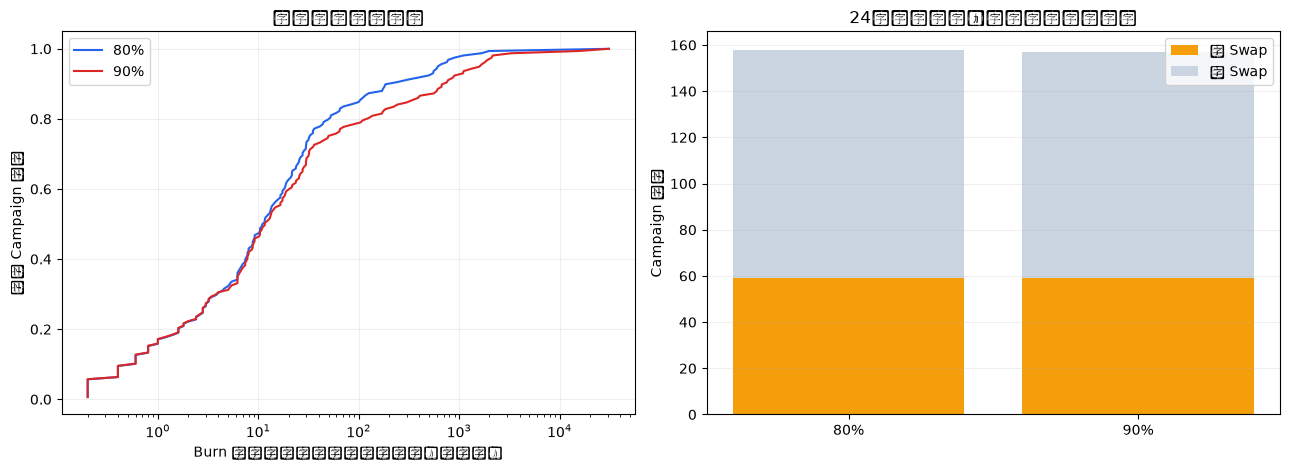

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for threshold, color in [(80, "#2563eb"), (90, "#dc2626")]:
    eligible = intervals[
        intervals.threshold_pct.eq(threshold) & intervals.threshold_recovery_observed
    ].drop_duplicates("campaign_id")
    minutes = ((eligible.recovery_timestamp - eligible.burn_timestamp) / 60).sort_values()
    axes[0].plot(minutes, np.arange(1, len(minutes)+1)/len(minutes), label=f"{threshold}%", color=color)
axes[0].set_xscale("log")
axes[0].set_xlabel("Burn 到首次达到恢复线的分钟数（对数轴）")
axes[0].set_ylabel("累计 Campaign 比例")
axes[0].set_title("恢复空窗时长分布")
axes[0].legend()
axes[0].grid(alpha=.2)

plot = gap_table[gap_table.观察范围.eq("24h")]
axes[1].bar(plot.恢复线, plot.空窗内有Swap的Campaign, label="有 Swap", color="#f59e0b")
axes[1].bar(plot.恢复线, plot.空窗内无Swap的Campaign, bottom=plot.空窗内有Swap的Campaign, label="无 Swap", color="#cbd5e1")
axes[1].set_title("24小时范围内：空窗是否碰上交易")
axes[1].set_ylabel("Campaign 数量")
axes[1].legend()
axes[1].grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()

## 2. 价格冲击怎么算？

对每笔 Swap，先取它发生前的池内价格，再读取 Swap 后事件记录的池价：

- 买入 TURBO：看池价被向上推了多少；
- 卖出 TURBO：看池价被向下推了多少；
- 统一换算成基点，`1 bp = 0.01%`。

例如价格冲击为20 bp，表示这笔 Swap 让池内中间价格沿交易方向移动约0.20%。它不等于用户实际滑点，因为用户报价、路由、最低成交限制和其他池都不在这个数字里。

In [4]:
primary = summary[summary.caliper_pct.eq(.25)].copy()
display(primary[[
    "threshold_pct", "horizon", "treated_swap_count", "treated_campaign_count",
    "matched_pair_count", "match_rate", "treated_median_price_impact_bps",
    "control_median_price_impact_bps", "median_excess_price_impact_bps",
    "mean_cluster_excess_price_impact_bps", "cluster_bootstrap_ci_low",
    "cluster_bootstrap_ci_high", "positive_excess_share",
]])

,threshold_pct,horizon,treated_swap_count,treated_campaign_count,matched_pair_count,match_rate,treated_median_price_impact_bps,control_median_price_impact_bps,median_excess_price_impact_bps,mean_cluster_excess_price_impact_bps,cluster_bootstrap_ci_low,cluster_bootstrap_ci_high,positive_excess_share
1,80,1h,196,55,195,0.994898,22.076499,18.725008,3.140007,5.790460,-14.259247,26.445741,0.733333
4,80,6h,387,59,386,0.997416,27.286258,18.217504,4.281396,4.143072,-16.035117,24.729461,0.772021
7,80,24h,561,59,558,0.994652,22.827668,16.289564,4.592756,11.375800,-4.124262,28.759093,0.772401
10,90,1h,201,54,200,0.995025,21.998128,18.734168,3.139327,5.873375,-14.619047,26.729801,0.730000
13,90,6h,434,59,433,0.997696,24.063239,17.367053,3.559296,-0.968420,-20.718637,18.637164,0.743649
16,90,24h,785,59,782,0.996178,22.227821,15.502406,3.342116,12.381168,-2.006413,27.727427,0.709719


## 3. 对照交易怎么选？

每笔空窗 Swap 都只和以下交易匹配：

1. 同一个池；
2. 同样是买 TURBO，或者同样是卖 TURBO；
3. WETH 等值成交额相差不超过25%；
4. 不处于任何 campaign 的90%空窗前24小时；
5. 选金额最接近的一笔，并且同一分析组内不重复使用控制交易。

主口径是±25%，同时把±10%和±50%作为敏感性检查。匹配率约99%，主口径中匹配金额比的中位数接近1，说明不是拿大单和小单硬比。

/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/152310581.py:22: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/152310581.py:22: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/152310581.py:22: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/152310581.py:22: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_82832/152310581.py:22: UserWarning: Glyph 20914 (\N{CJK UNIFIED IDEOGRAPH-51B2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5

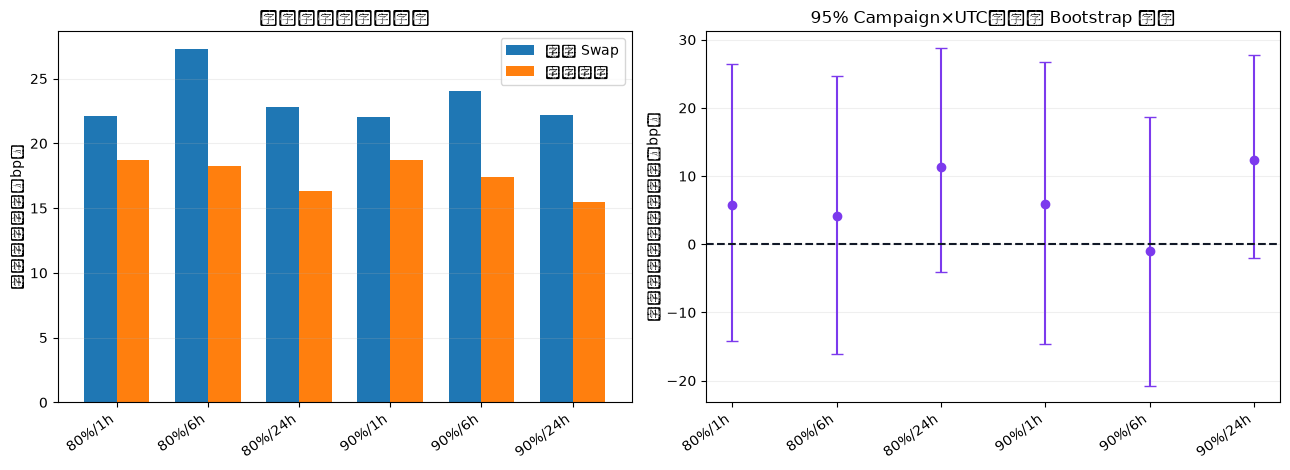

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(primary))
width = .36
labels = [f"{int(r.threshold_pct)}%/{r.horizon}" for r in primary.itertuples()]
axes[0].bar(x-width/2, primary.treated_median_price_impact_bps, width, label="空窗 Swap")
axes[0].bar(x+width/2, primary.control_median_price_impact_bps, width, label="匹配对照")
axes[0].set_xticks(x, labels, rotation=35, ha="right")
axes[0].set_ylabel("中位价格冲击（bp）")
axes[0].set_title("空窗交易与匹配对照")
axes[0].legend()
axes[0].grid(axis="y", alpha=.2)

estimate = primary.mean_cluster_excess_price_impact_bps.to_numpy()
low = primary.cluster_bootstrap_ci_low.to_numpy()
high = primary.cluster_bootstrap_ci_high.to_numpy()
axes[1].errorbar(x, estimate, yerr=[estimate-low, high-estimate], fmt="o", capsize=4, color="#7c3aed")
axes[1].axhline(0, color="#111827", linestyle="--")
axes[1].set_xticks(x, labels, rotation=35, ha="right")
axes[1].set_ylabel("聚类平均超额价格冲击（bp）")
axes[1].set_title("95% Campaign×UTC日聚类 Bootstrap 区间")
axes[1].grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()

In [6]:
primary_pairs = pairs[
    pairs.threshold_pct.eq(90) & pairs.horizon.eq("24h") & pairs.caliper_pct.eq(.25)
]
direction_table = primary_pairs.groupby("direction").agg(
    matched_pairs=("treated_swap_event_id", "size"),
    treated_median_bps=("treated_price_impact_bps", "median"),
    control_median_bps=("control_price_impact_bps", "median"),
    median_excess_bps=("excess_price_impact_bps", "median"),
    positive_excess_share=("excess_price_impact_bps", lambda values: (values > 0).mean()),
).reset_index()
display(Markdown("### 90% / 24小时主比较按交易方向拆开"))
display(direction_table)

display(Markdown("### 成交额相似度"))
display(primary_pairs.size_ratio.describe(percentiles=[.01, .25, .5, .75, .99]).to_frame())

### 90% / 24小时主比较按交易方向拆开

,direction,matched_pairs,treated_median_bps,control_median_bps,median_excess_bps,positive_excess_share
0,buy_turbo,364,29.001161,19.644845,3.335609,0.697802
1,sell_turbo,418,18.976237,12.993913,3.346740,0.720096


### 成交额相似度

,size_ratio
count,782.000000
mean,0.995359
std,0.027861
min,0.828520
1%,0.856987
25%,0.997001
50%,0.999673
75%,1.001036
99%,1.030846
max,1.202857


买入和卖出方向的配对中位差都约为正3.3 bp，说明结果不是只由单一交易方向造成的。可是“多数配对为正”仍不等于稳定的总体效应，因为许多 Swap 来自同一个 campaign 或同一天，不能把它们当成完全独立的几百次实验。

In [7]:
sensitivity = summary.pivot_table(
    index=["threshold_pct", "horizon"], columns="caliper_pct",
    values=["median_excess_price_impact_bps", "cluster_bootstrap_ci_low", "cluster_bootstrap_ci_high"]
)
display(sensitivity)

cluster_bootstrap_ci_high                        \
caliper_pct                                0.10       0.25       0.50   
threshold_pct horizon                                                   
80            1h                      26.445741  26.445741  26.445741   
              24h                     28.963867  28.759093  28.656519   
              6h                      24.729461  24.729461  24.729461   
90            1h                      26.729801  26.729801  26.729801   
              24h                     28.209661  27.727427  27.711088   
              6h                      18.886091  18.637164  18.637164   

                      cluster_bootstrap_ci_low                        \
caliper_pct                               0.10       0.25       0.50   
threshold_pct horizon                                                  
80            1h                    -14.259247 -14.259247 -14.259247   
              24h                    -4.078621  -4.124262  -4.146805   
              6h                    -16.035117 -16.035117 -16.035117   
90            1h                    -14.619047 -14.619047 -14.619047   
              24h                    -0.792610  -2.006413  -2.081195   
              6h                    -20.225719 -20.718637 -20.718637   

                      median_excess_price_impact_bps                      
caliper_pct                                     0.10      0.25      0.50  
threshold_pct horizon                                                     
80            1h                            3.140007  3.140007  3.140007  
              24h                           4.277079  4.592756  4.516111  
              6h                            4.281396  4.281396  4.281396  
90            1h                            3.139327  3.139327  3.139327  
              24h                           3.342116  3.342116  3.326091  
              6h                            3.564684  3.559296  3.559296

## 4. 当前可以得出什么结论？

**描述性结果：** 空窗内 Swap 的中位价格冲击在全部80%/90%和1h/6h/24h组合中都高于匹配对照，主口径的配对中位差约为 **3.1–4.6 bp**。10%、25%、50%成交额范围下方向基本一致。

**但还不能确认稳定放大：** 按 campaign×UTC日聚类后，六个主比较的95%区间全部跨过0。也就是说，正向中位差可能集中在少数 campaign/日期，现阶段不能写成“已经证明空窗稳定放大价格冲击”。

以90%恢复线、24小时为例：157个可定义恢复空窗的 campaign 中，59个在恢复前碰到至少一笔 Swap；共有785笔空窗 Swap，782笔找到±25%的合格对照。空窗 Swap 的中位冲击约22.23 bp，对照约15.50 bp，配对中位差约3.34 bp；但聚类平均差的95%区间约为 **-2.01 到 27.73 bp**。

因此，当前最稳妥的说法是：

> TURBO 样本中存在“空窗交易价格冲击偏高”的一致描述性迹象，但跨 campaign/日期的差异较大，尚不足以确认稳定的短期市场深度风险。

## 5. 这一步还不能说明什么？

- 不是因果实验：LP 可能在市场本来就更活跃或波动更大时撤出；
- 没有把交易者标记为套利者，也不能证明其掌握信息；
- 价格冲击不是用户实际滑点；
- 主要样本仍由同一个地址贡献，不能直接推广到所有代币和池；
- 当前匹配控制了池、方向和金额，但还没有单独控制撤资前的波动率与池内有效流动性。

如果继续收紧方案 A，下一次决策应在“加入撤资前波动率/有效流动性控制”与“当前证据已足够作为未确认结果，转向真实撤离追踪”之间选择。方案 C（手续费、Gas、无常损失和策略收益）继续留在 Phase 2，不在这里混入。

In [8]:
# 可复核底线。失败时 Notebook 会直接报错。
assert swaps.swap_event_id.is_unique
assert pairs.groupby(["threshold_pct", "horizon", "caliper_pct", "control_swap_event_id"]).size().max() == 1
assert (pairs.size_ratio >= 1 - pairs.caliper_pct - 1e-12).all()
assert (pairs.size_ratio <= 1 + pairs.caliper_pct + 1e-12).all()
assert set(pairs.direction) == {"buy_turbo", "sell_turbo"}
assert intervals[intervals.threshold_recovery_observed].observation_complete.all()
print("QA passed: Swap IDs unique; controls not reused within a comparison; direction and size rules satisfied.")

QA passed: Swap IDs unique; controls not reused within a comparison; direction and size rules satisfied.


## 6. 冻结输出

- `notebooks/data/turbo_lp_gap_impact_v1/swaps_with_price_impact_v1.parquet`
- `notebooks/data/turbo_lp_gap_impact_v1/gap_intervals_v1.parquet`
- `notebooks/data/turbo_lp_gap_impact_v1/gap_swap_exposure_v1.parquet`
- `notebooks/data/turbo_lp_gap_impact_v1/matched_swap_pairs_v1.parquet`
- `notebooks/data/turbo_lp_gap_impact_v1/gap_impact_summary_v1.csv`
- `notebooks/data/turbo_lp_gap_impact_v1/manifest.json`

这些文件只读取 Notebook 1 的冻结 campaign，不回写或改动事件分类。